In [46]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image

## Explore the arhchive:

In [41]:
folder_path = '/content/best_pictures/'

csv_count = 0
txt_count = 0
png_count = 0

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        csv_count += 1
    elif filename.endswith('.txt'):
        txt_count += 1
    elif filename.endswith('.png'):
        png_count += 1

print("File counts:")
print(f".csv: {csv_count}")
print(f".txt: {txt_count}")
print(f".png: {png_count}")

File counts:
.csv: 1
.txt: 1000
.png: 1000


## Load the .csv file with kernels:

In [8]:
csv_file = "/content/best_pictures/algos.csv"

fixed_kernels = pd.read_csv(csv_file, header=None)
fixed_kernels

,0,1,2,3,4,5,6,7,8
0,-1.0000,-0.5000,0.0000,-0.5000,0.5000,0.5000,0.0000,0.5000,1.0000
1,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625


### Convert dataframe into two matrices containing kernels:

In [11]:
fixed_kernel_1 = np.array(fixed_kernels.iloc[0]).reshape(3, 3)
fixed_kernel_2 = np.array(fixed_kernels.iloc[1]).reshape(3, 3)

## Define a custom net:

In [13]:
class CustomNet(nn.Module):
    def __init__(self, fixed_kernel_1: np.ndarray, fixed_kernel_2: np.ndarray):
        super(CustomNet, self).__init__()
        self.conv1_fixed = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.conv2_fixed = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.conv3_trainable = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self._initialize_fixed_layers(fixed_kernel_1, fixed_kernel_2)

        # Make fixed layers non-trainable
        self.conv1_fixed.requires_grad_(False)
        self.conv2_fixed.requires_grad_(False)

    def _initialize_fixed_layers(self, fixed_kernel_1, fixed_kernel_2):
        """Initialize the fixed layers with predefined kernels"""

        # Set the weights
        with torch.no_grad():
            self.conv1_fixed.weight.data = torch.tensor([
                [
                    fixed_kernel_1
                ]
            ], dtype=torch.float32)

            self.conv2_fixed.weight.data = torch.tensor([
                [
                    fixed_kernel_2
                ]
            ], dtype=torch.float32)

    def forward(self, x):
        x = self.conv3_trainable(x)
        x = self.conv2_fixed(x)
        x = self.conv1_fixed(x)

        return x

## Define a custom dataset class:

In [15]:
class ImageDataset(Dataset):
    def __init__(self, root_dir: str, transform = None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = sorted(
            [f for f in os.listdir(root_dir) if f.endswith(".png")],
            key = lambda x: int(x.split(".")[0])
        )
        self.text_files = sorted(
            [f for f in os.listdir(root_dir) if f.endswith(".txt")],
            key = lambda x: int(x.split(".")[0])
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image_name = os.path.join(self.root_dir, self.image_files[index])
        text_name = os.path.join(self.root_dir, self.text_files[index])

        image = np.array(Image.open(image_name))
        target_image = np.loadtxt(text_name)

        if self.transform:
            image = self.transform(image)
            # image = image * 255.0

            target_image = self.transform(target_image)
            # target_image = target_image * 255.0

        return image, target_image

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on {device}")

Training on cuda


In [44]:
dataset = ImageDataset(root_dir="/content/best_pictures", transform=transforms.ToTensor())
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

## Explore a train and target sample:

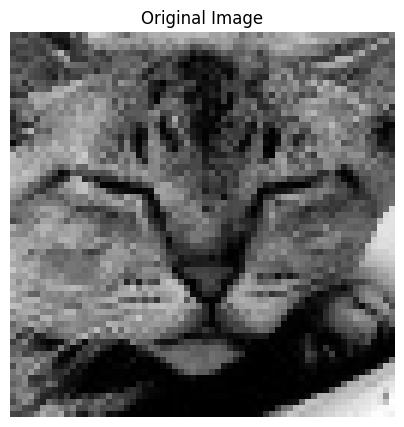

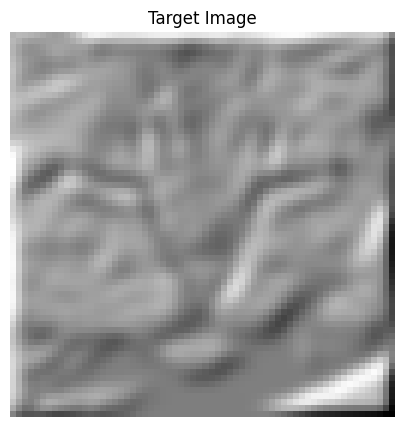

In [47]:
image, target_image = dataset[750]

plt.figure(figsize=(5, 5))
plt.imshow(image.squeeze(0).detach().numpy(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.figure(figsize=(5, 5))
plt.imshow(target_image.squeeze(0).detach().numpy(), cmap="gray")
plt.title("Target Image")
plt.axis("off")

plt.show()

In [50]:
model = CustomNet(fixed_kernel_1, fixed_kernel_2)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam([model.conv3_trainable.weight], lr=1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=2,
    factor=0.1,
    mode="min",
    verbose=True
)

num_epochs = 20

model.to(device)
model.train()
for i in range(num_epochs):
    running_loss = 0.0
    for batch, (x, y) in enumerate(dataloader):
        x, y = x.float().to(device), y.float().to(device)
        pred = model(x)
        loss = criterion(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    scheduler.step(epoch_loss)
    print(f"Epoch [{i+1}/{num_epochs}], Loss: {epoch_loss:.6f}. lr: {optimizer.param_groups[0]['lr']}")

    if epoch_loss == 0:
        break

Epoch [1/20], Loss: 231.243119. lr: 1
Epoch [2/20], Loss: 2.373755. lr: 1
Epoch [3/20], Loss: 0.281638. lr: 1
Epoch [4/20], Loss: 0.020412. lr: 1
Epoch [5/20], Loss: 0.003399. lr: 1
Epoch [6/20], Loss: 0.002943. lr: 1
Epoch [7/20], Loss: 0.002677. lr: 1
Epoch [8/20], Loss: 0.002295. lr: 1
Epoch [9/20], Loss: 0.001791. lr: 1
Epoch [10/20], Loss: 0.001336. lr: 1
Epoch [11/20], Loss: 0.022274. lr: 1
Epoch [12/20], Loss: 0.315169. lr: 1
Epoch [13/20], Loss: 0.000323. lr: 1
Epoch [14/20], Loss: 0.000249. lr: 1
Epoch [15/20], Loss: 0.014270. lr: 1
Epoch [16/20], Loss: 0.041972. lr: 1
Epoch [17/20], Loss: 0.000083. lr: 1
Epoch [18/20], Loss: 0.057638. lr: 1
Epoch [19/20], Loss: 0.000025. lr: 1
Epoch [20/20], Loss: 0.018762. lr: 1


## Extract kernels from a trained model:

In [51]:
model.to("cpu")

kernel_1 = model.conv3_trainable.weight.data.squeeze((0, 1)).numpy().reshape(1, -1) * 1/256
kernel_2 = model.conv2_fixed.weight.data.squeeze((0, 1)).numpy().reshape(1, -1)
kernel_3 = model.conv1_fixed.weight.data.squeeze((0, 1)).numpy().reshape(1, -1)

In [52]:
stacked = np.vstack([kernel_2, kernel_1, kernel_3])
np.savetxt("submission.csv", stacked, delimiter=",")

In [53]:
csv_file = "/content/submission.csv"

result = pd.read_csv(csv_file, header=None)
result

,0,1,2,3,4,5,6,7,8
0,0.062500,0.062500,0.062500,0.062500,0.062500,0.06250,0.062500,0.062500,0.062500
1,0.123864,0.250683,0.124125,0.250671,0.495106,0.25075,0.124066,0.250716,0.123912
2,-1.000000,-0.500000,0.000000,-0.500000,0.500000,0.50000,0.000000,0.500000,1.000000


In [54]:
fixed_kernels

,0,1,2,3,4,5,6,7,8
0,-1.0000,-0.5000,0.0000,-0.5000,0.5000,0.5000,0.0000,0.5000,1.0000
1,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625


## Show results:

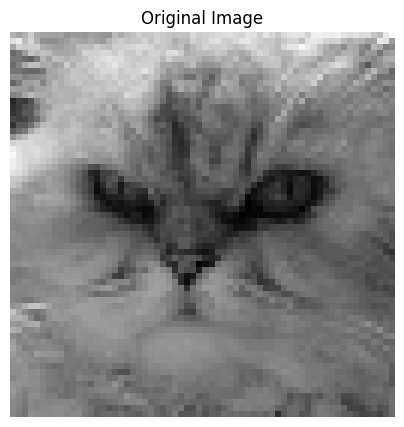

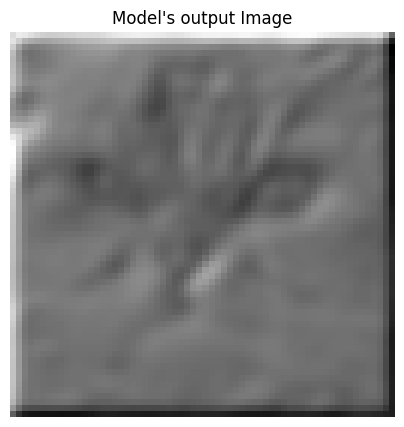

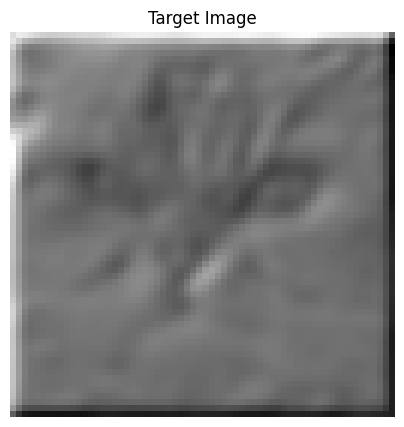

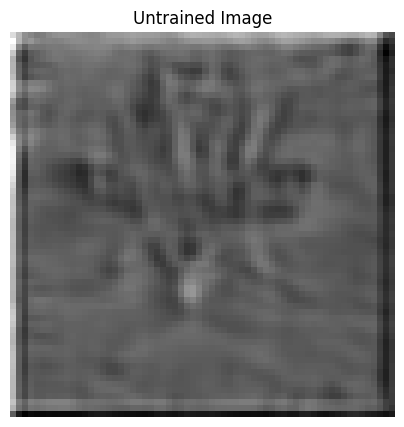

In [55]:
image, target_image = next(iter(dataset))
image, target_image = image.to("cpu"), target_image.to("cpu")
model.to("cpu")
model.eval()

output_image = model(image)
untrained_output_image = CustomNet(fixed_kernel_1, fixed_kernel_2)(image)

plt.figure(figsize=(5, 5))
plt.imshow(image.squeeze(0).detach().numpy(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.figure(figsize=(5, 5))
plt.imshow(output_image.squeeze(0).detach().numpy(), cmap="gray")
plt.title("Model's output Image")
plt.axis("off")

plt.figure(figsize=(5, 5))
plt.imshow(target_image.squeeze(0).detach().numpy(), cmap="gray")
plt.title("Target Image")
plt.axis("off")

plt.figure(figsize=(5, 5))
plt.imshow(untrained_output_image.squeeze(0).detach().numpy(), cmap="gray")
plt.title("Untrained Image")
plt.axis("off")

plt.show()

In [56]:
model.eval()
model.to("cuda")
total_loss = 0.0
with torch.no_grad():
    for data in dataloader:
        x, y = data
        x, y = x.to(device), y.to(device)

        y_pred = model(x)

        loss = criterion(y_pred, y)
        total_loss += loss.item()

In [57]:
total_loss

6.4220851344269345